In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In this problem, you will develop a model to predict whether a given</br>
car gets high or low gas mileage based on the Auto data set.</br>

In [26]:
from ISLP import load_data
auto = load_data('Auto')
auto

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
...,...,...,...,...,...,...,...,...,...
387,27.0,4,140.0,86,2790,15.6,82,1,ford mustang gl
388,44.0,4,97.0,52,2130,24.6,82,2,vw pickup
389,32.0,4,135.0,84,2295,11.6,82,1,dodge rampage
390,28.0,4,120.0,79,2625,18.6,82,1,ford ranger


| 變數               | 意義（中文）                                   | 
| ---------------- | ---------------------------------------- |
| **mpg**          | miles per gallon，一加侖汽油可跑的英里數 → 油耗（越高越省油） | 
| **mpg01**        | 基於 mpg 的二元分類：高油耗=1，低油耗=0（用中位數切分）         | 
| **cylinders**    | 氣缸數（如 4、6、8 缸） 氣缸越多，通常引擎越大、油耗越差 |
| **displacement** | 排氣量（立方英寸）        引擎大小指標，越大油耗通常越差  |
| **horsepower**   | 馬力，引擎輸出功率                          越大代表引擎更強，通常油耗較差  |
| **weight**       | 車重（磅）                             車越重越耗油           |
| **acceleration** | 從 0 加速到 60 mph 的秒數  加速性能，與油耗關係不強     |
| **year**         | 車款年份（70–82 年代資料） 年代越新，技術越省油       |


(a) Create a binary variable, mpg01, that contains a 1 if mpg contains</br>
a value above its median, and a 0 if mpg contains a value below</br>
its median. You can compute the median using the median()</br>
method of the data frame. Note you may find it helpful to add</br>
a column mpg01 to the data frame by assignment. </br>
Assuming you have stored the data frame as Auto, this can be done as follows:</br>
把 mpg 分成兩類：</br>
mpg 高 → 設為 1</br>
mpg 低 → 設為 0</br>
找出 mpg 的中位數</br>
建立新變數 mpg01</br>
mpg > 中位數 → 設成 1，否則設成 0</br>

In [27]:
mpg01 = (auto['mpg'] > auto['mpg'].median()).astype(int)
auto['mpg01'] = mpg01

# auto['mpg'] > auto['mpg'].median() → 會產生 True / False
# .astype(int) → 把 True → 1，False → 0

(b) Explore the data graphically in order to investigate the associ-</br>
ation between mpg01 and the other features. Which of the other</br>
features seem most likely to be useful in predicting mpg01? Scat-</br>
terplots and boxplots may be useful tools to answer this ques-</br>
tion. Describe your findings.</br>

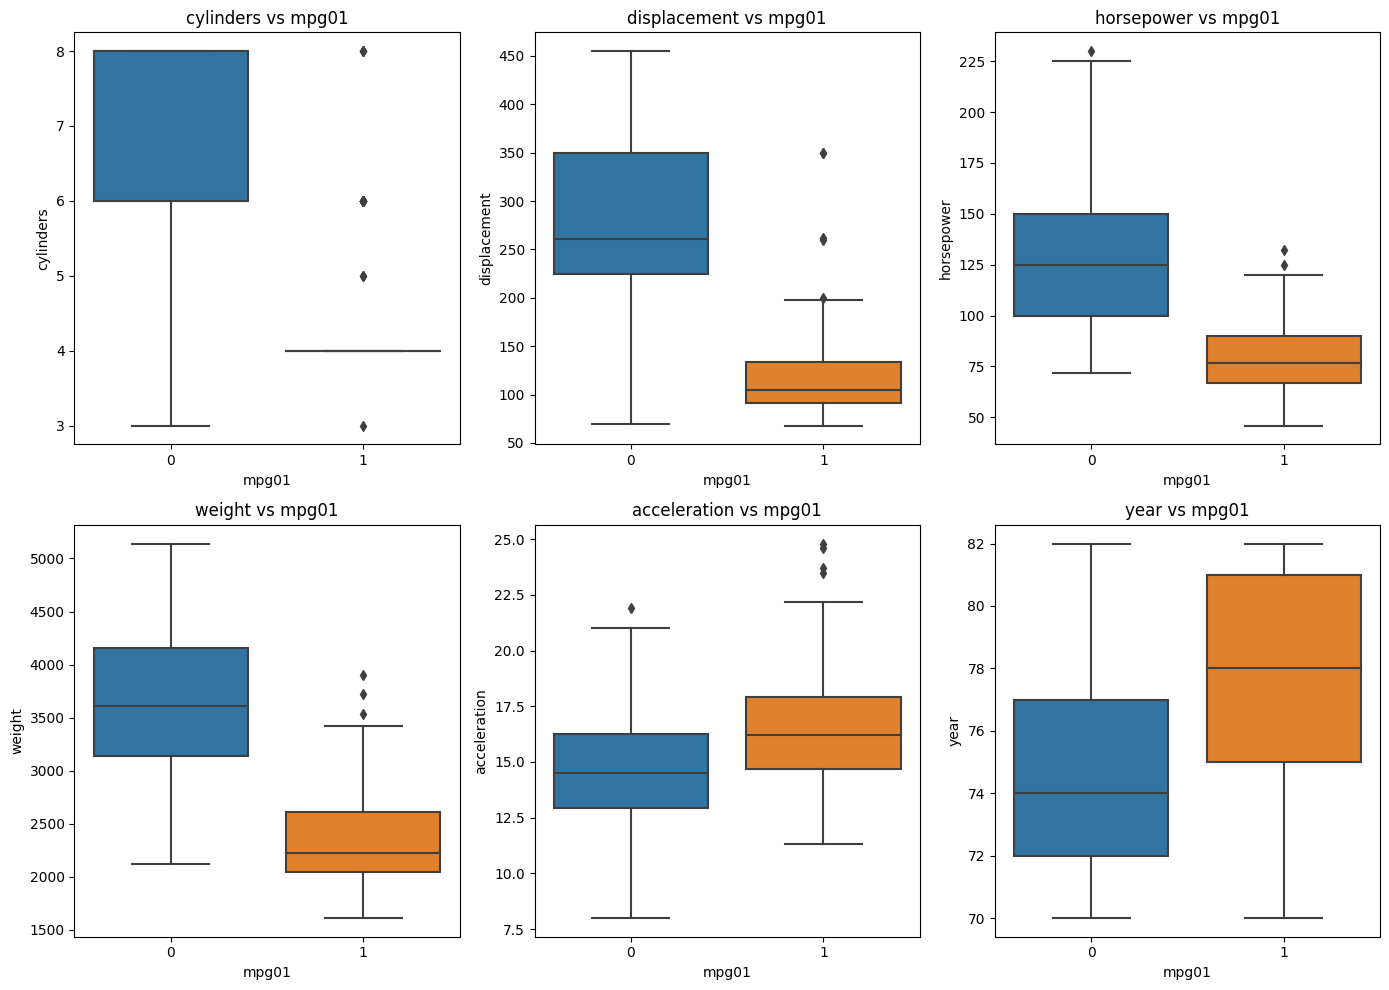

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

features = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

plt.figure(figsize=(14, 10))
for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='mpg01', y=col, data=auto)
    plt.title(f'{col} vs mpg01')

plt.tight_layout()
plt.show()


mpg01：高燃油效率(省油)=1 , 低燃油效率(耗油)=0</br>
mpg (miles per gallon) 表示每加侖汽油可以行駛的英里數，因此 mpg 值越高代表燃油效率越好、越省油。</br>
由此，mpg01 = 1 用來表示高 mpg（省油車），mpg01 = 0 則表示低 mpg（耗油車）。</br>

* cylinders：
  mpg01 = 0 多為 6–8 缸；mpg01 = 1 多為 4 缸
  → 氣缸越多越耗油

* displacement：
  mpg01 = 0 排氣量大；mpg01 = 1 排氣量小
  → 引擎越大越耗油

* horsepower：
  mpg01 = 0 馬力高；mpg01 = 1 馬力低
  → 功率越大燃料消耗越多

* weight：
  mpg01 = 0 車重高；mpg01 = 1 車重低
  → 車越重越耗油（差異最明顯）

* acceleration：
  兩組差異不明顯
  → 加速性能與油耗關聯弱

* year：
  mpg01 = 1 多為新年份；mpg01 = 0 多為舊年份
  → 新車油耗效率較好


(c) Split the data into a training set and a test set.

In [29]:
from sklearn.model_selection import train_test_split

features = ['weight', 'horsepower', 'displacement', 'cylinders']

# Features and target
X = auto[features]
y = auto['mpg01']

# Split the data: 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)
print("Training data size:", X_train.shape)
print("Test data size:", X_test.shape)


Training data size: (274, 4)
Test data size: (118, 4)


(d) Perform LDA on the training data in order to predict mpg01</br>
using the variables that seemed most associated with mpg01 in</br>
(b). What is the test error of the model obtained?</br>

Accuracy: 0.9152542372881356
Test Error: 0.0847457627118644


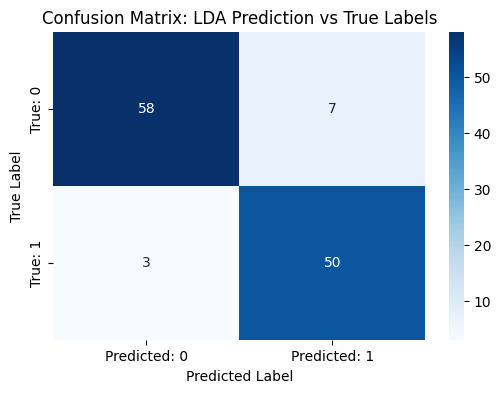

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 建立模型
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 預測
y_pred = lda.predict(X_test)

# 計算 accuracy
accuracy = accuracy_score(y_test, y_pred)

# test error
test_error = 1 - accuracy

print("Accuracy:", accuracy)
print("Test Error:", test_error)
# print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0','Predicted: 1'],
            yticklabels=['True: 0','True: 1'])

plt.title('Confusion Matrix: LDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


(e) Perform QDA on the training data in order to predict mpg01</br>
using the variables that seemed most associated with mpg01 in</br>
(b). What is the test error of the model obtained?</br>

Accuracy: 0.923728813559322
Test Error: 0.07627118644067798


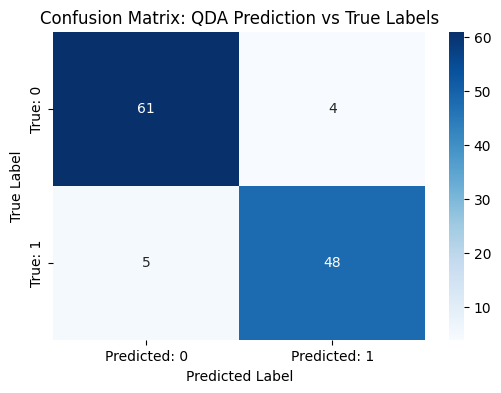

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Initialize and train the QDA model
qda_model = QuadraticDiscriminantAnalysis()
qda_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = qda_model.predict(X_test)

# 計算 accuracy
accuracy = accuracy_score(y_test, y_pred)

# test error
test_error = 1 - accuracy

print("Accuracy:", accuracy)
print("Test Error:", test_error)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0','Predicted: 1'],
            yticklabels=['True: 0','True: 1'])

plt.title('Confusion Matrix: QDA Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()


(f) Perform logistic regression on the training data in order to pre-</br>
dict mpg01 using the variables that seemed most associated with</br>
mpg01 in (b). What is the test error of the model obtained?</br>

Accuracy: 0.9067796610169492
Test Error: 0.09322033898305082


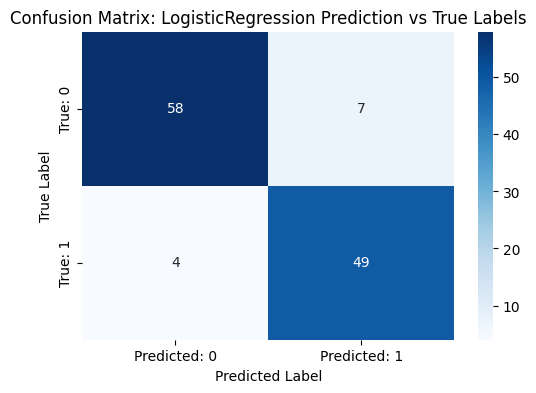

In [32]:
from sklearn.linear_model import LogisticRegression

# logistic regression model
logreg_model = LogisticRegression(solver='liblinear') #Specify a solver
logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

test_error = 1 - accuracy

print("Accuracy:", accuracy)
print("Test Error:", test_error)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0','Predicted: 1'],
            yticklabels=['True: 0','True: 1'])

plt.title('Confusion Matrix: LogisticRegression Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

(g) Perform naive Bayes on the training data in order to predict</br>
mpg01 using the variables that seemed most associated with mpg01</br>
in (b). What is the test error of the model obtained?</br>

Accuracy: 0.9152542372881356
Test Error: 0.0847457627118644


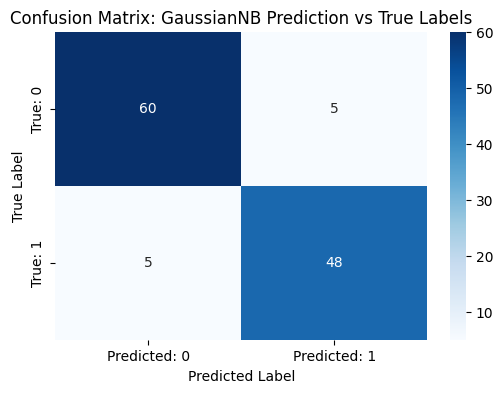

In [33]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

y_pred = nb_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

test_error = 1 - accuracy

print("Accuracy:", accuracy)
print("Test Error:", test_error)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: 0','Predicted: 1'],
            yticklabels=['True: 0','True: 1'])

plt.title('Confusion Matrix: GaussianNB Prediction vs True Labels')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

(h) Perform KNN on the training data, with several values of K, in</br>
order to predict mpg01. Use only the variables that seemed most</br>
associated with mpg01 in (b). What test errors do you obtain?</br>
Which value of K seems to perform the best on this data set?</br>

In [34]:
from sklearn.neighbors import KNeighborsClassifier

k_values = list(range(1, 21))
test_errors = []

for k in range(1, 21):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train, y_train)
    y_pred = knn_model.predict(X_test)
    test_error = 1 - accuracy_score(y_test, y_pred)
    test_errors.append(test_error)
    print(f"Test error for K = {k}: {test_error}")

# Find the best K
best_k = k_values[test_errors.index(min(test_errors))]
print(f"\nThe best K value is {best_k} with a test error of {min(test_errors)}")
     

Test error for K = 1: 0.11864406779661019
Test error for K = 2: 0.1271186440677966
Test error for K = 3: 0.11016949152542377
Test error for K = 4: 0.11016949152542377
Test error for K = 5: 0.13559322033898302
Test error for K = 6: 0.10169491525423724
Test error for K = 7: 0.10169491525423724
Test error for K = 8: 0.0847457627118644
Test error for K = 9: 0.10169491525423724
Test error for K = 10: 0.09322033898305082
Test error for K = 11: 0.1271186440677966
Test error for K = 12: 0.11016949152542377
Test error for K = 13: 0.1271186440677966
Test error for K = 14: 0.11864406779661019
Test error for K = 15: 0.11864406779661019
Test error for K = 16: 0.11864406779661019
Test error for K = 17: 0.1271186440677966
Test error for K = 18: 0.09322033898305082
Test error for K = 19: 0.11016949152542377
Test error for K = 20: 0.10169491525423724

The best K value is 8 with a test error of 0.0847457627118644
